<h1>Clustering k-Means</h1></th></tr></tbody></table>



In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt


Se va a trabajar con un dataset en 2D (fichero “ex7data2.mat”).


#### 1. En primer lugar implementaremos la función findClosestCentroids para asignar cada instancia del conjunto de training a su centroide más cercano, partiendo de los siguientes centroides iniciales de ejemplo: [[3, 3], [6,2], [8, 5]], es decir, K se inicializa a 3. Se usará la distancia euclídea para determinar qué centroide está más cerca. La función devuelve un array de m enteros.

In [2]:
X = sio.loadmat("ex7data2.mat")['X']
print("Shape de X: ",X.shape)

Shape de X:  (300, 2)


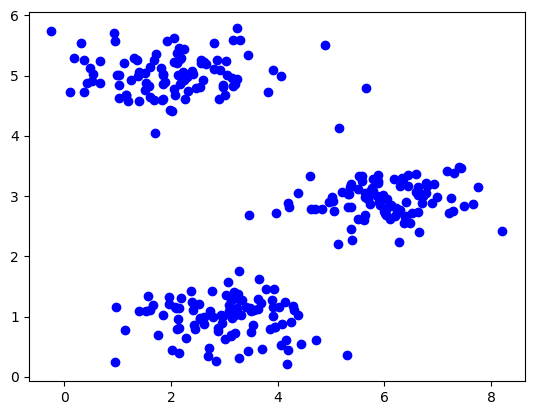

In [3]:
for i in range(len(X)):
    plt.scatter(X[i][0], X[i][1], color = "blue")
plt.show()    

In [ ]:
def findClosestCentroids(X, centroids):
    k = centroids.shape[0]
    cluster = []
    
    for data in X:
        euc_dist = []
        for j in range(k):
            euc_dist.append(np.sqrt(np.sum(np.abs(data - centroids[j])**2)))#aqui es donde definimos el calculo de la distancia
        cluster.append(np.argmin(euc_dist))#de todas las distancias euclideas calculadas elegimos el minimo y la agregamos al vector en cada iteración
    return np.asarray(cluster)        
    

In [6]:
#aplicamos la funcion findClosestCentroids

#Elegimos un k
k = 3
initial_centroids = np.array([[3.0,3.0], [6.0,2.0], [8.0,5.0]])

print("Buscando centroides más cercanos")
ids = findClosestCentroids(X, initial_centroids)
print("shape (forma) de ids: ",ids.shape)
print("Centroides más cercanos para los 3 primeros ejemplos: ",ids[0:3])

Buscando centroides más cercanos
shape (forma) de ids:  (300,)
Centroides más cercanos para los 3 primeros ejemplos:  [0 2 1]


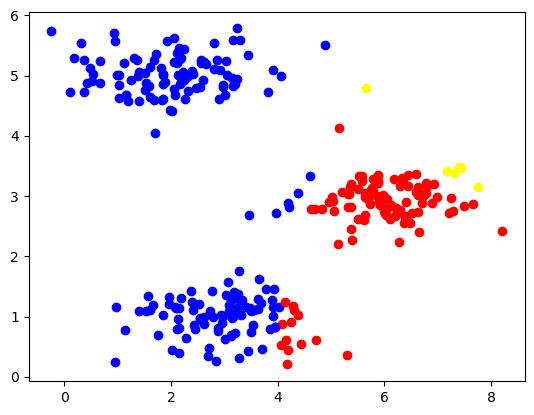

In [7]:
#Graficar centroides
for i in range(len(X)):
    if ids[i] == 0:
        plt.scatter(X[i][0], X[i][1], color = 'blue')
    if ids[i] == 1:
        plt.scatter(X[i][0], X[i][1], color = 'red')
    if ids[i] == 2:
        plt.scatter(X[i][0], X[i][1], color = 'yellow')

#### 2. Implementamos la función computeCentroids para recalcular los centroides a partir de las asignaciones realizadas por la función findClosestCentroids. Para cada cluster, se calcula la media de las instancias que le han sido asignadas, obteniendo así el nuevo centroide.



In [8]:
def computeCentroids(X, clusters, K):
    centroids = []
    for i in range(K):
        arr_aux = []
        
        for j in range(len(X)):
            if clusters[j] == i:
                arr_aux.append(X[j])

        if len(arr_aux) == 0:
            centroids.append(X[np.random.randint(0, len(X))])
        else:
                
            centroids.append(np.mean(arr_aux, axis = 0))
     
    return np.asarray(centroids)           

#### 3. Implementamos la función runKmeans que llama a las dos funciones anteriores para ver cómo funciona el algoritmo usando los centroides iniciales creados anteriormente y 10 iteraciones. Realizaremos también una función que represente los clusters finales e iniciales que será usada también dentro del cuerpo de runKmeans.



In [9]:
def plotClusters(X,clusters,centroids,ini_centroids):
    #Asignamos un color a cada cluster
    cols={0:'b',1:'g',2:'coral',3:'c',4:'lime'}
    fig,ax=plt.subplots()

    #Representamos el punto de cada cluster
    for i in range(len(clusters)):
        ax.scatter(X[i][0],X[i][1],color=cols[clusters[i]], marker="+")

    #Representamos todos los centroides y los señalamos con un círculo
    for j in range(len(centroids)):
        #Representsmos centroides finales
        ax.scatter(centroids[j][0],centroids[j][1],color=cols[j]) #PONE UN PUNTO PARA EL FINAL
        ax.add_artist(plt.Circle((centroids[j][0], centroids[j][1]), 0.4, linewidth=2, fill=False)) #ARTIST LE PONE UN CIRCULO
        #Representamos centroides iniciales con ^ y un circulo amarillo
        ax.scatter(ini_centroids[j][0],ini_centroids[j][1],marker="^",s=150,color=cols[j]) #PONE UN ^ PARA EL INICIAL
        ax.add_artist(plt.Circle((ini_centroids[j][0], ini_centroids[j][1]), 0.4, linewidth=2, color='y', fill=False))

    ax.set_xlabel("Característica 1")
    ax.set_ylabel("Característica 2")
    ax.set_title("K-means Clustering")
    plt.show()

In [10]:

def runKmeans(X, initial_centroids, max_iters, plot=False):

    k = initial_centroids.shape[0]# 3
    centroids = initial_centroids
    idx = np.zeros((X.shape[0]))
    
    for i in range(max_iters):
        print("\tk-Means iteración: ",i,"/",max_iters)
        idx = findClosestCentroids(X, centroids)
        centroids = computeCentroids(X, idx, k)
    if plot == True:
        plotClusters(X, idx, centroids, initial_centroids)

    return centroids, idx

	k-Means iteración:  0 / 10
	k-Means iteración:  1 / 10
	k-Means iteración:  2 / 10
	k-Means iteración:  3 / 10
	k-Means iteración:  4 / 10
	k-Means iteración:  5 / 10
	k-Means iteración:  6 / 10
	k-Means iteración:  7 / 10
	k-Means iteración:  8 / 10
	k-Means iteración:  9 / 10


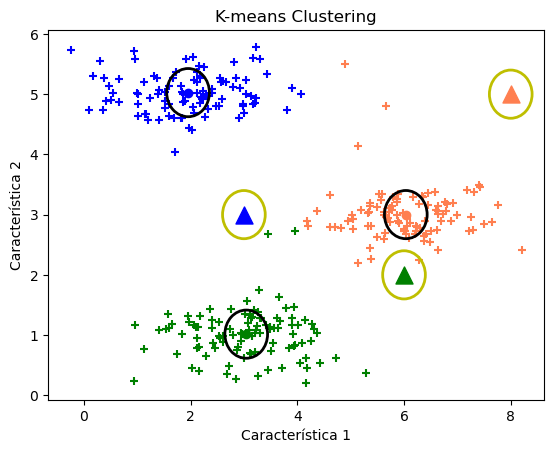

Centroides calculados tras  10 iteraciones de k-mean con inicialización manual de los centroides:
 [[1.95399466 5.02557006]
 [3.04367119 1.01541041]
 [6.03366736 3.00052511]]


In [11]:
#Ejecutamos el algoritmo Kmeans
max_iters = 10 
centroids, idx = runKmeans(X, initial_centroids, max_iters, plot = True)
print("Centroides calculados tras ", max_iters, "iteraciones de k-mean con inicialización manual de los centroides:\n",centroids)

#### Para no tener que inicializar los centroides a mano, crearemos una función que los inicialize de forma aleatoria por nosostros. Esta inicialización de los centroides selecciona al azar K instancias del conjunto de entrenamiento.


In [12]:
#definifmos y aplicamos la funcion kMeansInitCentroids
def kMeansInitCentroids(X, k):
  centroids = []
  m, n = X.shape
  centroids = np.zeros((k, n))
  idx = np.random.randint(0, m, k)
  for i in range(k):
      centroids[i] = X[idx[i]]
  return centroids 

kMeansInitCentroids(X,3)

array([[3.31058167, 1.03124461],
       [2.02358978, 0.44771614],
       [4.8255341 , 2.77961664]])

#### El algoritmo K-means es muy eficiente por su lógica de agrupamiento simple, sin embargo, presenta un inconveniente, y es que el valor del k depende del tamaño del dataset y estimarlo de forma empírica no es una metodología práctica y fiable. Es por ello que aplicaremos uno de los métodos más famosos para estimarlo conocido como método del codo (Elbow Method). Crearemos la función elbowMethod.

In [13]:
def elbowMethod(X):
    J1 = []
    ks = range(1, 11) #Probamos de 1 a 10
    for k in ks:
        # Ejecutamos el K-means
        random_init = kMeansInitCentroids(X, k)
        centroids, idx = runKmeans(X, random_init, 10, plot=False)
        
        #Sumamos distancias al cuadrado de los 300 puntos
        curr_cost = 0
        for i in range(X.shape[0]):
            curr_cost += np.sum((X[i] - centroids[int(idx[i])])**2)
        J1.append(curr_cost / X.shape[0])

    plt.plot(ks, J1, marker='o', c="blue") #Con ks nos aseguramos que el eje X sea correcto
    plt.show()

	k-Means iteración:  0 / 10
	k-Means iteración:  1 / 10
	k-Means iteración:  2 / 10
	k-Means iteración:  3 / 10
	k-Means iteración:  4 / 10
	k-Means iteración:  5 / 10
	k-Means iteración:  6 / 10
	k-Means iteración:  7 / 10
	k-Means iteración:  8 / 10
	k-Means iteración:  9 / 10
	k-Means iteración:  0 / 10
	k-Means iteración:  1 / 10
	k-Means iteración:  2 / 10
	k-Means iteración:  3 / 10
	k-Means iteración:  4 / 10
	k-Means iteración:  5 / 10
	k-Means iteración:  6 / 10
	k-Means iteración:  7 / 10
	k-Means iteración:  8 / 10
	k-Means iteración:  9 / 10
	k-Means iteración:  0 / 10
	k-Means iteración:  1 / 10
	k-Means iteración:  2 / 10
	k-Means iteración:  3 / 10
	k-Means iteración:  4 / 10
	k-Means iteración:  5 / 10
	k-Means iteración:  6 / 10
	k-Means iteración:  7 / 10
	k-Means iteración:  8 / 10
	k-Means iteración:  9 / 10
	k-Means iteración:  0 / 10
	k-Means iteración:  1 / 10
	k-Means iteración:  2 / 10
	k-Means iteración:  3 / 10
	k-Means iteración:  4 / 10
	k-Means iteración: 

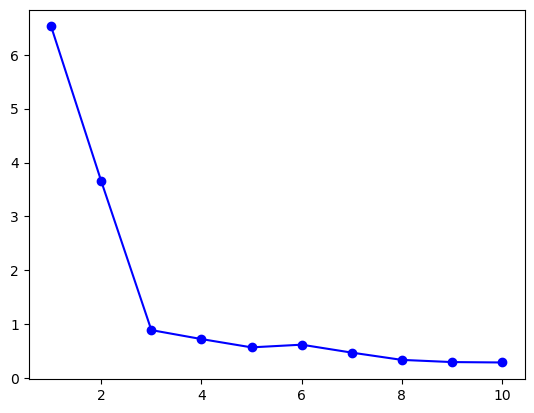

In [14]:
#Aplicamos método del codo
elbowMethod(X)